# Hotel Booking Cancellation Prediction
## Decision Tree → Random Forest → Gradient Boosting → XGBoost → LightGBM → CatBoost

**Goal:** predict `is_canceled` from information available when a reservation is made.

We compare six tree-based classifiers, evaluate them with Accuracy, Precision, Recall, F1, ROC-AUC and PR-AUC, tune them, analyze errors and save the best model.

### Core mathematics
- Entropy: $H(S)=-\sum_k p_k\log_2 p_k$
- Information Gain: $IG=H(S)-\sum_j\frac{|S_j|}{|S|}H(S_j)$
- Random Forest: $\hat y=\operatorname{mode}(T_1(x),...,T_B(x))$
- Boosting: $F_m(x)=F_{m-1}(x)+\eta h_m(x)$
- Logistic probability used by boosting classifiers: $p=\sigma(F(x))=1/(1+e^{-F(x)})$

Import Modules

In [13]:
import time, warnings, joblib
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay, roc_curve,
                             precision_recall_curve)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Load the Kaggle dataset

In [14]:
DATA_PATH = Path("./data/hotel_bookings.csv")
if not DATA_PATH.exists():
        raise FileNotFoundError("Upload the Hotel Booking Demand dataset to Kaggle first.")

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()

Shape: (119390, 32)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


## 2. Data understanding

In [15]:
df.info()
display(df.describe(include="all").T)
print("\nMissing values:")
display(df.isna().sum().sort_values(ascending=False).head(15))
print("Duplicate rows:", df.duplicated().sum())
print("Target distribution:")
display(df["is_canceled"].value_counts(normalize=True).rename("proportion"))

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
hotel,119390,2,City Hotel,79330,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_canceled,119390.0,NaN,NaN,NaN,0.370416,0.482918,0.0,0.0,0.0,1.0,1.0
lead_time,119390.0,NaN,NaN,NaN,104.011416,106.863097,0.0,18.0,69.0,160.0,737.0
arrival_date_year,119390.0,NaN,NaN,NaN,2016.156554,0.707476,2015.0,2016.0,2016.0,2017.0,2017.0
arrival_date_month,119390,12,August,13877,NaN,NaN,NaN,NaN,NaN,NaN,NaN
arrival_date_week_number,119390.0,NaN,NaN,NaN,27.165173,13.605138,1.0,16.0,28.0,38.0,53.0
arrival_date_day_of_month,119390.0,NaN,NaN,NaN,15.798241,8.780829,1.0,8.0,16.0,23.0,31.0
stays_in_weekend_nights,119390.0,NaN,NaN,NaN,0.927599,0.998613,0.0,0.0,1.0,2.0,19.0
stays_in_week_nights,119390.0,NaN,NaN,NaN,2.500302,1.908286,0.0,1.0,2.0,3.0,50.0
adults,119390.0,NaN,NaN,NaN,1.856403,0.579261,0.0,2.0,2.0,2.0,55.0



Missing values:


company                      112593
agent                         16340
country                         488
children                          4
arrival_date_month                0
arrival_date_week_number          0
hotel                             0
is_canceled                       0
stays_in_weekend_nights           0
arrival_date_day_of_month         0
adults                            0
stays_in_week_nights              0
babies                            0
meal                              0
lead_time                         0
dtype: int64

Duplicate rows: 31994
Target distribution:


is_canceled
0    0.629584
1    0.370416
Name: proportion, dtype: float64

## 3. Cleaning and exploratory analysis

We remove exact duplicates. Missing `children`, `country`, `agent`, and `company` are handled later by model-specific preprocessing; this avoids accidentally using information from the test set.

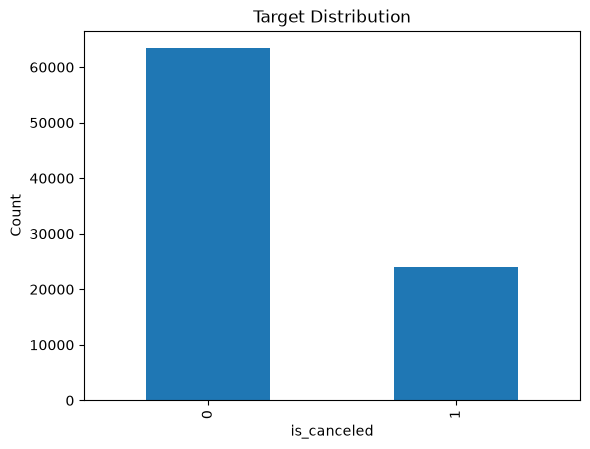

,cancellation_rate
hotel,
City Hotel,0.300386
Resort Hotel,0.234809


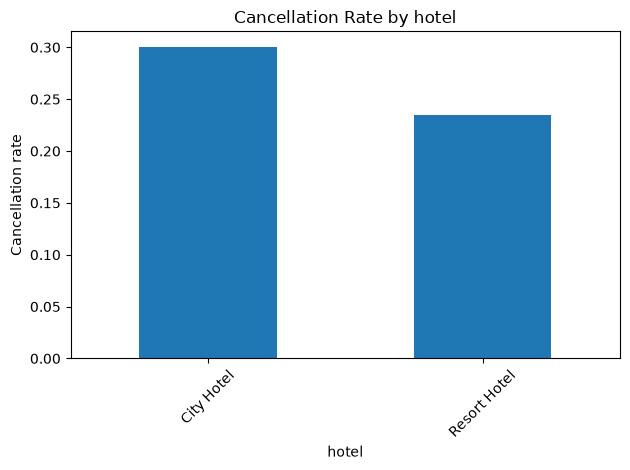

,cancellation_rate
market_segment,
Undefined,1.000000
Online TA,0.353462
Groups,0.270134
Aviation,0.198238
Offline TA/TO,0.148535
Direct,0.147154
Complementary,0.125356
Corporate,0.121083


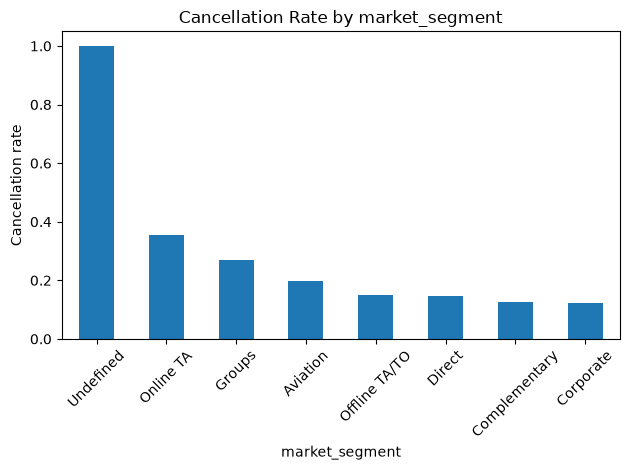

,cancellation_rate
deposit_type,
Non Refund,0.947013
No Deposit,0.266849
Refundable,0.242991


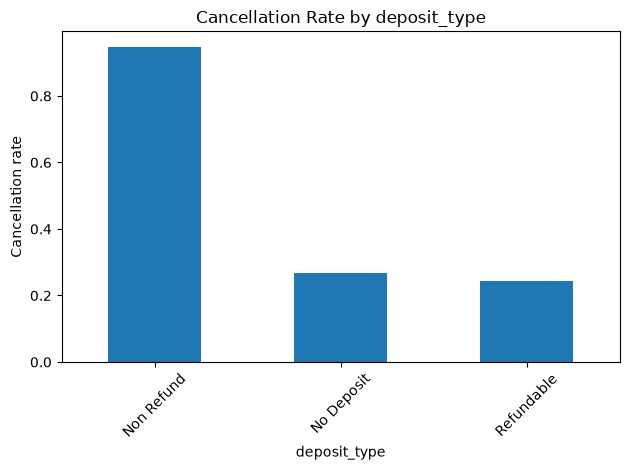

In [16]:
df = df.drop_duplicates().copy()

fig, ax = plt.subplots()
df["is_canceled"].value_counts().sort_index().plot(kind="bar", ax=ax)
ax.set_xlabel("is_canceled")
ax.set_ylabel("Count")
ax.set_title("Target Distribution")
plt.show()

for col in ["hotel", "market_segment", "deposit_type"]:
    rates = df.groupby(col)["is_canceled"].mean().sort_values(ascending=False)
    display(rates.to_frame("cancellation_rate"))
    rates.plot(kind="bar", title=f"Cancellation Rate by {col}")
    plt.ylabel("Cancellation rate"); plt.xticks(rotation=45); plt.tight_layout(); plt.show()

## 4. Feature engineering

We create features that summarize reservation behavior while avoiding post-booking leakage. For a realistic prediction-at-booking task, we exclude `reservation_status`, `reservation_status_date`, `assigned_room_type`, and `booking_changes` because they can contain information that occurs after the original booking decision.

In [18]:
def engineer_features(data):
    data = data.copy()
    data["total_nights"] = data["stays_in_weekend_nights"] + data["stays_in_week_nights"]
    data["total_guests"] = data["adults"] + data["children"].fillna(0) + data["babies"]
    data["has_children"] = (data["children"].fillna(0) > 0).astype(int)
    data["has_babies"] = (data["babies"] > 0).astype(int)
    data["has_previous_cancellations"] = (data["previous_cancellations"] > 0).astype(int)
    data["adr_per_guest"] = data["adr"] / data["total_guests"].replace(0, np.nan)
    return data

df_model = engineer_features(df)
TARGET = "is_canceled"
DROP_COLUMNS = [TARGET, "reservation_status", "reservation_status_date",
                "assigned_room_type", "booking_changes"]
X = df_model.drop(columns=DROP_COLUMNS)
y = df_model[TARGET].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
print(X_train.shape, X_test.shape)

(69916, 33) (17480, 33)


## 5. Preprocessing for sklearn, XGBoost and LightGBM

Categorical columns are one-hot encoded. Numeric columns use median imputation. `agent` and `company` are retained as categorical variables here; if memory becomes an issue on Kaggle, they can be removed from the one-hot models while remaining available to CatBoost.

In [19]:
categorical_features = X_train.select_dtypes(include=["object"]).columns.tolist()
numerical_features = X_train.select_dtypes(exclude=["object"]).columns.tolist()

preprocessor = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), numerical_features),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical_features)
])

X_train_enc = preprocessor.fit_transform(X_train)
X_test_enc = preprocessor.transform(X_test)
feature_names = preprocessor.get_feature_names_out()
print("Encoded shape:", X_train_enc.shape)

Encoded shape: (69916, 243)


## 6. Define the six models

In [20]:
models = {
    "Decision Tree": DecisionTreeClassifier(criterion="entropy", max_depth=8, min_samples_leaf=10, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=12, min_samples_leaf=2, max_features="sqrt", n_jobs=-1, random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=3, min_samples_leaf=10, random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=5, min_child_weight=2, subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0, objective="binary:logistic", eval_metric="logloss", n_jobs=-1, random_state=RANDOM_STATE),
    "LightGBM": LGBMClassifier(n_estimators=300, learning_rate=0.05, num_leaves=31, min_child_samples=30, subsample=0.8, subsample_freq=1, colsample_bytree=0.8, reg_lambda=1.0, n_jobs=-1, verbosity=-1, random_state=RANDOM_STATE),
    "CatBoost": CatBoostClassifier(iterations=300, learning_rate=0.05, depth=6, loss_function="Logloss", eval_metric="AUC", verbose=False, random_seed=RANDOM_STATE)
}

for name, model in models.items():
    print(name, type(model).__name__)

Decision Tree DecisionTreeClassifier
Random Forest RandomForestClassifier
Gradient Boosting GradientBoostingClassifier
XGBoost XGBClassifier
LightGBM LGBMClassifier
CatBoost CatBoostClassifier


## 7. Baseline training and evaluation

In [22]:
def evaluate_model(model, Xtr, Xte, ytr, yte):
    start = time.perf_counter()
    model.fit(Xtr, ytr)
    fit_time = time.perf_counter() - start
    start = time.perf_counter()
    pred = model.predict(Xte)
    prob = model.predict_proba(Xte)[:, 1]
    pred_time = time.perf_counter() - start
    return {
        "Accuracy": accuracy_score(yte, pred),
        "Precision": precision_score(yte, pred, zero_division=0),
        "Recall": recall_score(yte, pred, zero_division=0),
        "F1": f1_score(yte, pred, zero_division=0),
        "ROC-AUC": roc_auc_score(yte, prob),
        "PR-AUC": average_precision_score(yte, prob),
        "Fit_Time_sec": fit_time,
        "Prediction_Time_sec": pred_time
    }

trained = {}
baseline_rows = []
for name in ["Decision Tree", "Random Forest", "Gradient Boosting", "XGBoost", "LightGBM"]:
    result = evaluate_model(models[name], X_train_enc, X_test_enc, y_train, y_test)
    trained[name] = models[name]
    baseline_rows.append({"Model": name, **result})

# CatBoost handles categorical features directly

Xtr_cat = X_train.copy()
Xte_cat = X_test.copy()

# Convert categorical columns to strings
for c in categorical_features:
    Xtr_cat[c] = Xtr_cat[c].fillna("Unknown").astype(str)
    Xte_cat[c] = Xte_cat[c].fillna("Unknown").astype(str)


def evaluate_catboost(model, Xtr, Xte, ytr, yte, categorical_features):
    start = time.perf_counter()

    model.fit(
        Xtr,
        ytr,
        cat_features=categorical_features
    )

    fit_time = time.perf_counter() - start

    start = time.perf_counter()

    pred = model.predict(Xte)
    prob = model.predict_proba(Xte)[:, 1]

    pred_time = time.perf_counter() - start

    return {
        "Accuracy": accuracy_score(yte, pred),
        "Precision": precision_score(yte, pred, zero_division=0),
        "Recall": recall_score(yte, pred, zero_division=0),
        "F1": f1_score(yte, pred, zero_division=0),
        "ROC-AUC": roc_auc_score(yte, prob),
        "PR-AUC": average_precision_score(yte, prob),
        "Fit_Time_sec": fit_time,
        "Prediction_Time_sec": pred_time
    }


# Evaluate CatBoost
cat_result = evaluate_catboost(
    models["CatBoost"],
    Xtr_cat,
    Xte_cat,
    y_train,
    y_test,
    categorical_features
)

trained["CatBoost"] = models["CatBoost"]

baseline_rows.append({
    "Model": "CatBoost",
    **cat_result
})

baseline_results = (
    pd.DataFrame(baseline_rows)
    .sort_values("ROC-AUC", ascending=False)
)

display(baseline_results)


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Fit_Time_sec,Prediction_Time_sec
4,LightGBM,0.844279,0.740809,0.666805,0.701862,0.910649,0.800956,0.951967,0.146161
5,CatBoost,0.839416,0.742593,0.636420,0.685420,0.904880,0.789981,27.847818,0.167942
3,XGBoost,0.839359,0.746239,0.629761,0.683070,0.902846,0.786475,1.482884,0.065672
2,Gradient Boosting,0.825572,0.747743,0.551509,0.634807,0.880812,0.742754,34.801888,0.140650
1,Random Forest,0.798627,0.823027,0.340687,0.481896,0.871648,0.734839,9.188264,0.330408
0,Decision Tree,0.807609,0.699392,0.526327,0.600641,0.862681,0.661086,0.903994,0.008803


In [23]:
for name, model in trained.items():
    if name == "CatBoost":
        pred = model.predict(Xte_cat).astype(int).ravel()
    else:
        pred = model.predict(X_test_enc)
    print("\n###", name)
    print(classification_report(y_test, pred, digits=4))


### Decision Tree
              precision    recall  f1-score   support

           0     0.8358    0.9142    0.8733     12675
           1     0.6994    0.5263    0.6006      4805

    accuracy                         0.8076     17480
   macro avg     0.7676    0.7203    0.7370     17480
weighted avg     0.7983    0.8076    0.7983     17480


### Random Forest
              precision    recall  f1-score   support

           0     0.7955    0.9722    0.8750     12675
           1     0.8230    0.3407    0.4819      4805

    accuracy                         0.7986     17480
   macro avg     0.8093    0.6565    0.6785     17480
weighted avg     0.8031    0.7986    0.7670     17480


### Gradient Boosting
              precision    recall  f1-score   support

           0     0.8454    0.9295    0.8854     12675
           1     0.7477    0.5515    0.6348      4805

    accuracy                         0.8256     17480
   macro avg     0.7966    0.7405    0.7601     17480
weighted avg 

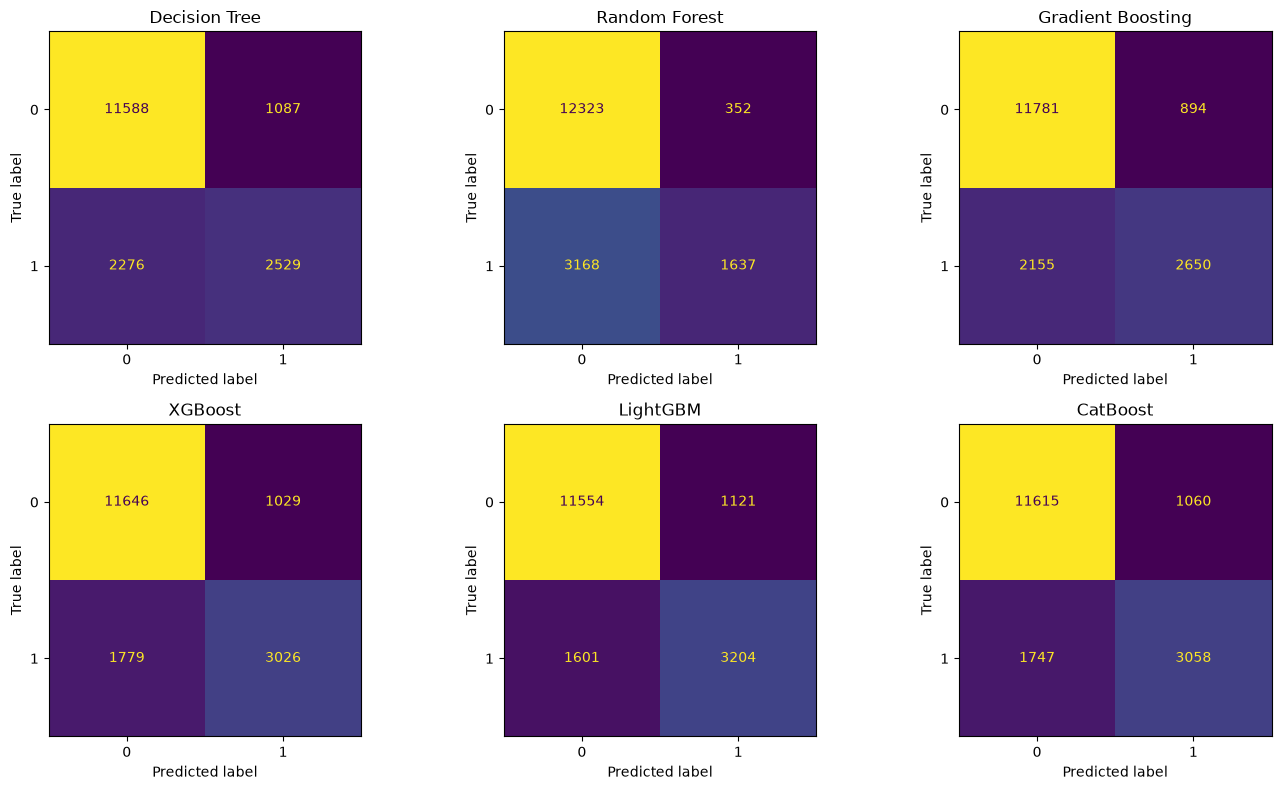

In [24]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, (name, model) in zip(axes.ravel(), trained.items()):
    if name == "CatBoost":
        pred = model.predict(Xte_cat).astype(int).ravel()
    else:
        pred = model.predict(X_test_enc)
    ConfusionMatrixDisplay(confusion_matrix(y_test, pred)).plot(ax=ax, colorbar=False)
    ax.set_title(name)
plt.tight_layout(); plt.show()

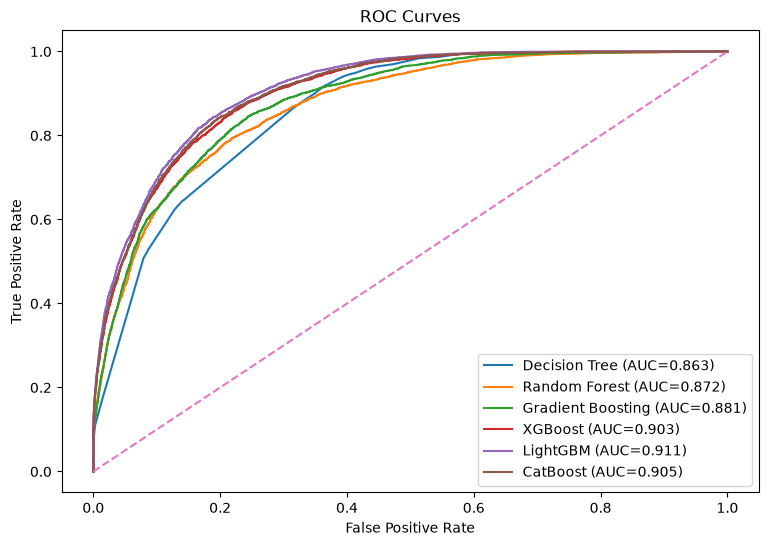

In [25]:
plt.figure(figsize=(9, 6))
for name, model in trained.items():
    if name == "CatBoost":
        prob = model.predict_proba(Xte_cat)[:, 1]
    else:
        prob = model.predict_proba(X_test_enc)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate"); plt.title("ROC Curves"); plt.legend(); plt.show()

## 8. Hyperparameter tuning

ROC-AUC is used as the tuning objective because it evaluates ranking quality across classification thresholds. To keep a Kaggle notebook practical, `QUICK_MODE=True` uses fewer random-search iterations. Set it to `False` for a larger search.

In [26]:
QUICK_MODE = True
N_ITER = 5 if QUICK_MODE else 15
CV = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

search_spaces = {
    "Decision Tree": {
        "max_depth": [3,5,7,10,15,None], "min_samples_split": [2,5,10,20],
        "min_samples_leaf": [1,2,5,10,20], "max_features": [None,"sqrt","log2"]
    },
    "Random Forest": {
        "n_estimators": [200,300,500], "max_depth": [None,8,12,16,20],
        "min_samples_split": [2,5,10], "min_samples_leaf": [1,2,5],
        "max_features": ["sqrt","log2",0.5]
    },
    "Gradient Boosting": {
        "n_estimators": [100,200,300], "learning_rate": [0.02,0.05,0.1],
        "max_depth": [2,3,4,5], "min_samples_leaf": [5,10,20], "subsample": [0.7,0.85,1.0]
    },
    "XGBoost": {
        "n_estimators": [200,300,500], "learning_rate": [0.02,0.05,0.1],
        "max_depth": [3,4,5,6,8], "min_child_weight": [1,2,5,10],
        "subsample": [0.7,0.8,1.0], "colsample_bytree": [0.7,0.8,1.0],
        "reg_lambda": [0.5,1.0,2.0,5.0]
    },
    "LightGBM": {
        "n_estimators": [200,300,500], "learning_rate": [0.02,0.05,0.1],
        "num_leaves": [15,31,50,75], "max_depth": [-1,5,8,12],
        "min_child_samples": [10,20,30,50], "subsample": [0.7,0.8,1.0],
        "colsample_bytree": [0.7,0.8,1.0], "reg_lambda": [0.0,1.0,5.0]
    },
    "CatBoost": {
        "iterations": [200,300,500], "learning_rate": [0.02,0.05,0.1],
        "depth": [4,5,6,7,8], "l2_leaf_reg": [1,3,5,10], "random_strength": [0,0.5,1,2]
    }
}

base_estimators = {
    "Decision Tree": DecisionTreeClassifier(criterion="entropy", random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_jobs=-1, random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(objective="binary:logistic", eval_metric="logloss", n_jobs=-1, random_state=RANDOM_STATE),
    "LightGBM": LGBMClassifier(verbosity=-1, n_jobs=-1, random_state=RANDOM_STATE),
    "CatBoost": CatBoostClassifier(loss_function="Logloss", verbose=False, random_seed=RANDOM_STATE, thread_count=1)
}

tuned = {}
tuning_rows = []
for name, estimator in base_estimators.items():
    print(f"Tuning {name}...")
    if name == "CatBoost":
        search = RandomizedSearchCV(estimator, search_spaces[name], n_iter=N_ITER, scoring="roc_auc", cv=CV, random_state=RANDOM_STATE, n_jobs=1, verbose=0)
        search.fit(Xtr_cat, y_train, cat_features=categorical_features)
        best = search.best_estimator_
        pred = best.predict(Xte_cat).astype(int).ravel()
        prob = best.predict_proba(Xte_cat)[:,1]
    else:
        search = RandomizedSearchCV(estimator, search_spaces[name], n_iter=N_ITER, scoring="roc_auc", cv=CV, random_state=RANDOM_STATE, n_jobs=-1, verbose=0)
        search.fit(X_train_enc, y_train)
        best = search.best_estimator_
        pred = best.predict(X_test_enc)
        prob = best.predict_proba(X_test_enc)[:,1]
    tuned[name] = best
    tuning_rows.append({
        "Model": name, "CV_Best_ROC_AUC": search.best_score_,
        "Test_ROC_AUC": roc_auc_score(y_test, prob),
        "Test_PR_AUC": average_precision_score(y_test, prob),
        "Test_F1": f1_score(y_test, pred, zero_division=0),
        "Best_Params": search.best_params_
    })

tuning_results = pd.DataFrame(tuning_rows).sort_values("Test_ROC_AUC", ascending=False)
display(tuning_results)

Tuning Decision Tree...
Tuning Random Forest...
Tuning Gradient Boosting...
Tuning XGBoost...
Tuning LightGBM...
Tuning CatBoost...


,Model,CV_Best_ROC_AUC,Test_ROC_AUC,Test_PR_AUC,Test_F1,Best_Params
4,LightGBM,0.911920,0.913896,0.807064,0.709149,"{'subsample': 0.8, 'reg_lambda': 5.0, 'num_lea..."
1,Random Forest,0.909351,0.912096,0.803920,0.709529,"{'n_estimators': 300, 'min_samples_split': 10,..."
3,XGBoost,0.906616,0.907039,0.794511,0.693923,"{'subsample': 0.8, 'reg_lambda': 1.0, 'n_estim..."
5,CatBoost,0.905129,0.905963,0.791203,0.688711,"{'random_strength': 1, 'learning_rate': 0.1, '..."
2,Gradient Boosting,0.882800,0.881891,0.746580,0.635516,"{'subsample': 0.7, 'n_estimators': 100, 'min_s..."
0,Decision Tree,0.789856,0.792899,0.569769,0.632019,"{'min_samples_split': 10, 'min_samples_leaf': ..."


## 9. Compare tuned models

In [27]:
rows=[]
for name, model in tuned.items():
    if name == "CatBoost":
        pred=model.predict(Xte_cat).astype(int).ravel(); prob=model.predict_proba(Xte_cat)[:,1]
    else:
        pred=model.predict(X_test_enc); prob=model.predict_proba(X_test_enc)[:,1]
    rows.append({"Model":name, "Accuracy":accuracy_score(y_test,pred),
                 "Precision":precision_score(y_test,pred,zero_division=0),
                 "Recall":recall_score(y_test,pred,zero_division=0),
                 "F1":f1_score(y_test,pred,zero_division=0),
                 "ROC-AUC":roc_auc_score(y_test,prob),
                 "PR-AUC":average_precision_score(y_test,prob)})

tuned_results=pd.DataFrame(rows).sort_values("ROC-AUC",ascending=False)
display(tuned_results)
BEST_NAME=tuned_results.iloc[0]["Model"]
print("Best model by ROC-AUC:", BEST_NAME)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
4,LightGBM,0.847769,0.746777,0.675130,0.709149,0.913896,0.807064
1,Random Forest,0.848284,0.748902,0.674089,0.709529,0.912096,0.803920
3,XGBoost,0.841533,0.739694,0.653486,0.693923,0.907039,0.794511
5,CatBoost,0.840046,0.740484,0.643704,0.688711,0.905963,0.791203
2,Gradient Boosting,0.825515,0.746281,0.553382,0.635516,0.881891,0.746580
0,Decision Tree,0.798684,0.635141,0.628928,0.632019,0.792899,0.569769


Best model by ROC-AUC: LightGBM


## 10. Feature importance

For one-hot models, importance is reported for encoded features. CatBoost reports importance on the original columns.

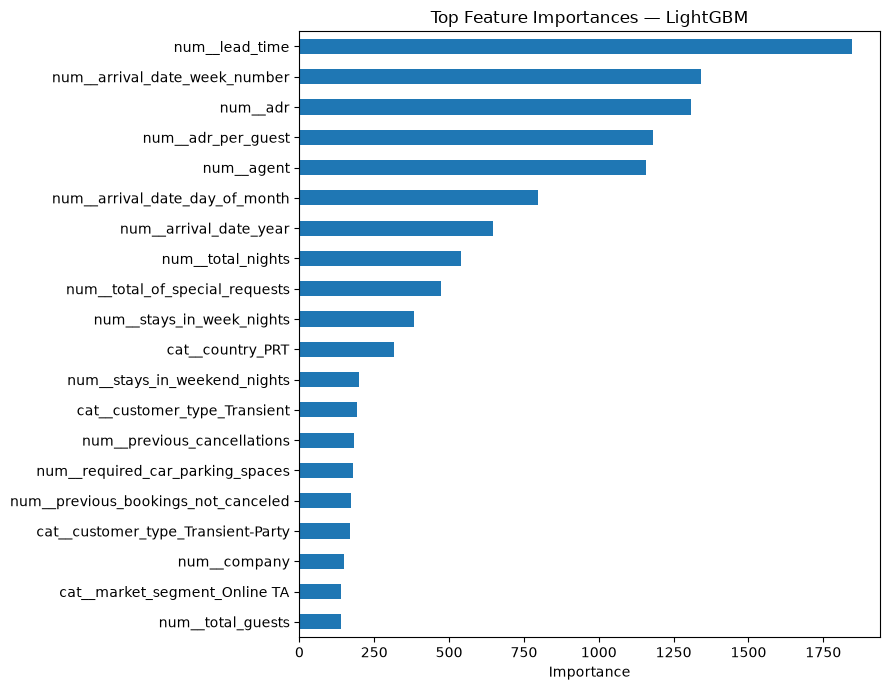

,importance
num__lead_time,1847
num__arrival_date_week_number,1341
num__adr,1307
num__adr_per_guest,1181
num__agent,1159
num__arrival_date_day_of_month,798
num__arrival_date_year,646
num__total_nights,541
num__total_of_special_requests,474
num__stays_in_week_nights,383


In [28]:
best_model=tuned[BEST_NAME]
if BEST_NAME == "CatBoost":
    imp=pd.Series(best_model.get_feature_importance(), index=X_train.columns).sort_values(ascending=False).head(20)
else:
    imp=pd.Series(best_model.feature_importances_, index=feature_names).sort_values(ascending=False).head(20)

imp.sort_values().plot(kind="barh", figsize=(9,7), title=f"Top Feature Importances — {BEST_NAME}")
plt.xlabel("Importance"); plt.tight_layout(); plt.show()
display(imp.to_frame("importance"))